In [1]:
# standard python tools
import os
import random
import copy
import time

# math and plotting
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# scikit for the 10-fold CV
from sklearn.model_selection import StratifiedKFold

# pytorch setup
import torch
import torch.nn as nn
from torch import Tensor 
import torch.nn.functional as F
from torch.nn import Sequential, Linear, ReLU, BatchNorm1d, ModuleList, Parameter
from torch.utils.data import Subset

# pytorch geometric setup
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.typing import OptTensor, Optional
from torch_geometric.utils import degree, to_undirected, add_self_loops, softmax
from torch_geometric.nn.inits import glorot, zeros
from torch_geometric.nn import (
    GCNConv, 
    GraphConv, 
    GATv2Conv,
    GINConv, 
    GINEConv,
    GATConv, 
    TransformerConv, 
    global_add_pool, 
    global_mean_pool,
    MessagePassing
)

In [2]:
# pytorch geometric dataloaders work well with python lists,
# but they need to also have .num_features and .num_classes
# this wrapper treats the list like a proper dataset object
class ListDataset(list):
    def __init__(self, data_list, num_features, num_classes):
        super().__init__(data_list)
        self.num_features = num_features
        self.num_classes = num_classes

In [3]:
# sanity-check: gpu available?
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
# sanity-check: which torch version?
os.environ['TORCH'] = torch.__version__
print("Torch version: ", torch.__version__)

Using device: cuda
Torch version:  2.9.0+cu130


In [4]:
# reproducability is key, set the seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed(42)

In [5]:
def degree_cov(edge_index, num_nodes):
    # this is the main metric for the paper.
    # it measures how much the node degrees vary across the graph.
    # high cov = high variance of node degrees
    
    # edge case: if the graph has no edges, there is no variation.
    # catching this early so it doesn't crash later.
    if edge_index.numel() == 0:
        return 0.0, torch.zeros(num_nodes)

    # get the degree (number of connections) for each node
    deg = degree(edge_index[0], num_nodes=num_nodes).float()

    # calculate the average degree.
    # i am clamping the minimum to a tiny number (1e-9)
    # to avoid dividing by zero if the graph is empty or disconnected.
    deg_mean = deg.mean().clamp(min=1e-9)

    # the formula is: standard deviation divided by the mean.
    cov = deg.std(unbiased=False) / deg_mean

    return cov.item(), deg

In [6]:
def _edge_key(u, v):
    # helper to handle undirected edges
    # i want to make sure that (1, 2) and (2, 1) are treated as the exact same edge.
    # so i enforce the rule "the smaller node index always comes first"
    return (u, v) if u < v else (v, u)

In [7]:
# telling pytorch not to track gradients here.
# since this is just a pre-processing step (rewiring the graph), 
# i don't need backprop. this helps save memory.
@torch.no_grad()
def modify_graph_rcov(data, target_cov, max_new_edges=1000):
    
    # i need to work on a copy of the graph data so i don't ruin the original dataset.
    data = data.clone()
    num_nodes = data.num_nodes
    
    # initialize edge features (edge_attr is what the model uses)
    # the rcov method relies on the original edges having a 'strong' weight (1.0).
    # i ensure the feature tensor is 2d: [num_edges, 1]
    if data.edge_attr is None:
        # fix: ensure the tensor is 2d (size 1 feature dimension)
        data.edge_attr = torch.ones((data.edge_index.size(1), 1), dtype=torch.float)
    
    # check initial status and stop early if possible
    # i calculate the current variation (cov) to see where we start.
    curr_cov, deg = degree_cov(data.edge_index, num_nodes)
    
    # if the graph is already perfectly regular (cov is 0), or if we are already
    # below the target smoothness, i don't need to add any edges.
    if curr_cov == 0:
        return data

    if curr_cov <= target_cov:
        return data

    # iterative modification: the main smoothing loop
    # i clone the degrees so i can update them in the loop without recalculating the cov every time.
    current_deg = deg.clone()
    # i use a set for quick checking if an edge already exists (it's faster than a list).
    existing_edges = set(_edge_key(u.item(), v.item()) for u, v in data.edge_index.t())
    new_edges_list = []
    
    iteration = 0
    # i loop until i hit the smoothness target or run out of attempts
    while iteration < max_new_edges:
        
        # check if the current variation is smooth enough
        mean = current_deg.mean().clamp(min=1e-9)
        std = current_deg.std(unbiased=False)
        if (std / mean) <= target_cov:
            break
            
        # i sort the nodes by degree to find the ones with the fewest connections
        sorted_indices = torch.argsort(current_deg)
        
        # heuristic: i only look at the bottom 10 nodes to save time on searching.
        # connecting the 'loneliest' nodes is the fastest way to reduce variation.
        k = min(num_nodes, 10)
        candidates = sorted_indices[:k]
        
        found_pair = False
        
        # greedy search: i try to connect the first valid pair within my candidate pool
        for i in range(len(candidates)):
            if found_pair: break
            u = candidates[i].item()
            
            for j in range(i + 1, len(candidates)):
                v = candidates[j].item()
                
                # i don't want self-loops (node connecting to itself)
                if u == v: continue
                
                # check if the edge already exists
                key = _edge_key(u, v)
                if key not in existing_edges:
                    # found a pair! i record the new undirected edge (two directed entries)
                    new_edges_list.append([u, v])
                    new_edges_list.append([v, u])
                    existing_edges.add(key)
                    
                    # i update the degrees immediately so the next iteration uses the new, lower variation
                    current_deg[u] += 1
                    current_deg[v] += 1
                    found_pair = True
                    break
        
        # if i couldn't find any valid pair in my candidate pool, i break the loop
        if not found_pair:
            break
        iteration += 1
        
    # apply final changes to the graph object
    if new_edges_list:
        new_edge_index = torch.tensor(new_edges_list, dtype=torch.long).t()
        
        # marking these new edges as 'weak' (0.5), as specified in the paper. 
        # fix: the feature tensor must be 2d [num_edges, 1]
        new_edge_attr = torch.full((new_edge_index.size(1), 1), 0.5, dtype=torch.float)
        
        # i concatenate the new edges to the index
        data.edge_index = torch.cat([data.edge_index, new_edge_index], dim=1)
        
        # fix: i concatenate the old and new edge features (this prevents the runtime error)
        data.edge_attr = torch.cat([data.edge_attr, new_edge_attr], dim=0)
        
    return data

In [8]:
def create_rcov_dataset_and_log(dataset_orig, target_ratio, num_features, num_classes):
    print(f"Generating R-COV({target_ratio}) dataset...")
    
    # i calculate the average variation across all original graphs.
    orig_covs = []
    total_orig_directed_edges = 0
    
    for data in dataset_orig:
        # we calculate the current cov and store it for the dataset average.
        c, _ = degree_cov(data.edge_index, data.num_nodes)
        orig_covs.append(c)
        total_orig_directed_edges += data.edge_index.size(1)
    
    avg_dataset_cov = np.mean(orig_covs)
    # the threshold for every graph is set as a fixed percentage of this average.
    target_cov = avg_dataset_cov * target_ratio
    
    print("-" * 30)
    print(f"Dataset Avg COV (Original): {avg_dataset_cov:.4f}")
    print(f"Target Ratio:               {target_ratio}")
    print(f"Target COV Threshold:       {target_cov:.4f}")
    print("-" * 30)

    # now i apply the graph modification logic to every graph in the dataset.
    rcov_list = [
        # the modify_graph_rcov function handles the per-graph rewiring until the threshold is met.
        modify_graph_rcov(data, target_cov) 
        for data in dataset_orig
    ]

    # i calculate the final statistics across the newly modified graphs.
    new_covs = []
    total_final_directed_edges = 0
    total_weight_1_edges = 0
    total_weight_05_edges = 0
    
    for data in rcov_list:
        # calculate the final cov for this modified graph
        c, _ = degree_cov(data.edge_index, data.num_nodes)
        new_covs.append(c)
        
        total_final_directed_edges += data.edge_index.size(1)
        
        # we count the original edges (weight 1.0) and the new r-cov edges (weight 0.5)
        if data.edge_attr is not None:
             total_weight_1_edges += torch.sum(data.edge_attr == 1.0).item()
             total_weight_05_edges += torch.sum(data.edge_attr == 0.5).item()
             
    avg_new_cov = np.mean(new_covs)
    percentage = (avg_new_cov / avg_dataset_cov) * 100 if avg_dataset_cov > 1e-9 else 0.0

    print(f"Dataset Avg COV (Result):   {avg_new_cov:.4f}")
    print(f"Percentage of Original:     {percentage:.2f}%")
    print("-" * 30)
    
    print("Edge Statistics (Total Directed Edges)")
    print(f"Original Total Edges:       {total_orig_directed_edges}")
    print(f"Final Total Edges:          {total_final_directed_edges}")
    print(f"Edges w/ weight 1.0 (Orig): {total_weight_1_edges}")
    print(f"Edges w/ weight 0.5 (New):  {total_weight_05_edges}")
    print("-" * 30)

    # i wrap the modified list of graphs into the custom dataset class and return it.
    return ListDataset(rcov_list, num_features, num_classes)

In [9]:
print("Loading dataset...")
# download the data, including the node features
dataset_raw = TUDataset(root='data/TUDataset', name='REDDIT-BINARY')

# the rcov method relies on edge weights (1.0 for real, 0.5 for added).
# most graph datasets won't have edge attributes, so i need to manually 
# fill them in with 1.0s to represent "strong/original" connections.
dataset_orig_list = []
for data in dataset_raw:
    # node features: add degree as a node feature if none
    if data.x is None:
        deg = degree(data.edge_index[0], num_nodes=data.num_nodes)
        data.x = deg.view(-1, 1)  # [num_nodes, 1]

    # edge attributes: 1.0 for all original edges
    if data.edge_attr is None:
        data.edge_attr = torch.ones((data.edge_index.size(1), 1), dtype=torch.float)

    dataset_orig_list.append(data)

# infer in_channels correctly *after* preprocessing
# MDB-B: dataset_raw.num_features == 0, but our graphs now have x.shape[1] == 1
if dataset_raw.num_features == 0:
    num_features = dataset_orig_list[0].x.size(1)    
else:
    num_features = dataset_raw.num_features

num_classes = dataset_raw.num_classes

# 3) wrap into your ListDataset
dataset_orig = ListDataset(dataset_orig_list, num_features, num_classes)

print("Final num_features:", num_features)
print("Example x.shape:", dataset_orig[0].x.shape)
print("Example edge_attr.shape:", dataset_orig[0].edge_attr.shape)

Loading dataset...
Final num_features: 1
Example x.shape: torch.Size([218, 1])
Example edge_attr.shape: torch.Size([480, 1])


In [10]:
# data preprocessing:
# i am applying the rewiring logic to every single graph in the dataset.
# target_ratio=0.8 means i'm adding edges until the variation in node degrees
# drops to 80% of its original value.
dataset_rcov_80 = create_rcov_dataset_and_log(
    dataset_orig=dataset_orig, 
    target_ratio=0.8, 
    num_features=num_features, 
    num_classes=num_classes
)

Generating R-COV(0.8) dataset...
------------------------------
Dataset Avg COV (Original): 3.8422
Target Ratio:               0.8
Target COV Threshold:       3.0738
------------------------------
Dataset Avg COV (Result):   2.9306
Percentage of Original:     76.27%
------------------------------
Edge Statistics (Total Directed Edges)
Original Total Edges:       1991016
Final Total Edges:          2754266
Edges w/ weight 1.0 (Orig): 1991016
Edges w/ weight 0.5 (New):  763250
------------------------------


In [11]:
# data preprocessing:
# ditto here with 50% of the original value of COV
dataset_rcov_50 = create_rcov_dataset_and_log(
    dataset_orig=dataset_orig, 
    target_ratio=0.5, 
    num_features=num_features, 
    num_classes=num_classes
)

Generating R-COV(0.5) dataset...
------------------------------
Dataset Avg COV (Original): 3.8422
Target Ratio:               0.5
Target COV Threshold:       1.9211
------------------------------
Dataset Avg COV (Result):   2.4135
Percentage of Original:     62.82%
------------------------------
Edge Statistics (Total Directed Edges)
Original Total Edges:       1991016
Final Total Edges:          3312702
Edges w/ weight 1.0 (Orig): 1991016
Edges w/ weight 0.5 (New):  1321686
------------------------------


In [12]:
# dictionary to hold all datasets
all_datasets = {
    "Original": dataset_orig,
    "RCOV_0.8": dataset_rcov_80,
    "RCOV_0.5": dataset_rcov_50
}

In [13]:
# dataset-Level metrics
print(f'Dataset Analysis: {dataset_raw}')
dataset = dataset_raw
print('============================================')

# gathering stats from every single graph in the list.
all_num_nodes = [data.num_nodes for data in dataset]
all_num_edges = [data.num_edges for data in dataset]

# basic averages
avg_nodes = np.mean(all_num_nodes)
avg_edges_raw = np.mean(all_num_edges)

# important fix: pyg stores undirected edges as two directed edges (u->v and v->u).
# this means the raw count is double the actual number of connections.
# i need to divide by 2 to get the "human" definition of an edge count.
is_undirected = dataset[0].is_undirected()
avg_edges = avg_edges_raw / 2 if is_undirected else avg_edges_raw

print(f"{'Metric':<20} | {'Value'}")
print("-" * 35)
print(f"{'# Graphs':<20} | {len(dataset)}")
print(f"{'Avg # Nodes':<20} | {avg_nodes:.2f}")
print(f"{'Avg # Edges':<20} | {avg_edges:.2f}")
print(f"{'# Node Features':<20} | {dataset.num_features}")
print(f"{'# Classes':<20} | {dataset.num_classes}")
print(f"{'Is Undirected?':<20} | {is_undirected}")
print("-" * 35)

# i want to see what the node features actually look like.
# are they normalized? are there huge outliers?
# evaluating this across the entire dataset at once.
if dataset.num_features > 0:
    print("\nGlobal Node Feature Statistics (across all graphs):")
    
    # concatenate all the node features from every graph into one giant tensor
    # so i can use pandas to get the mean/std/min/max easily.
    all_x = torch.cat([d.x for d in dataset if d.x is not None], dim=0)
    df = pd.DataFrame(all_x.numpy())
    print(df.describe().round(2))
    
else:
    print("\n(No node features available in this dataset)")

# diving into a specific example (graph 0) to explore
# the structure and make sure the labels look right.
data = dataset[0]
print('\n------------------------')
print(f'Example Graph (ID: 0):')
print(f'Nodes: {data.num_nodes}')
print(f'Edges (PyG index size): {data.num_edges}')
print(f'Label: {data.y.item()}')

# checking connectivity stats for this specific graph
deg = degree(data.edge_index[0], data.num_nodes)
print(f'Avg Degree (this graph): {deg.mean().item():.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')

Dataset Analysis: REDDIT-BINARY(2000)
Metric               | Value
-----------------------------------
# Graphs             | 2000
Avg # Nodes          | 429.63
Avg # Edges          | 497.75
# Node Features      | 0
# Classes            | 2
Is Undirected?       | True
-----------------------------------

(No node features available in this dataset)

------------------------
Example Graph (ID: 0):
Nodes: 218
Edges (PyG index size): 480
Label: 1
Avg Degree (this graph): 2.20
Has isolated nodes: False
Has self-loops: False


In [14]:
class DeepSets(torch.nn.Module):
    # this is the baseline model for the case of "no graph structure"
    # it treats the graph as a "bag of nodes" and completely ignores any edges.
    # if my complex gnns don't beat this, then the graph structure wasn't useful.
    def __init__(self, num_features, num_classes, hidden_channels=64, num_layers=3, dropout=0.0):
        super().__init__()

        # we add dropout as per the paper
        self.dropout_val = dropout
        
        # building the node-level mlp.
        # i'm doing this dynamically with a list so i can easily 
        # change the number of layers (num_layers) during experiments
        # as defined in the paper
        layers = []
        
        # input layer
        layers.append(Linear(num_features, hidden_channels))
        layers.append(ReLU())
        
        # hidden layers (stacking them up based on num_layers)
        for _ in range(num_layers - 1):
            layers.append(Linear(hidden_channels, hidden_channels))
            layers.append(ReLU())

        # bundling it all into a sequential container
        self.node_mlp = Sequential(*layers)

        # the final classifier that runs after pooling
        self.classifier_mlp = Sequential(
            Linear(hidden_channels, hidden_channels), ReLU(),
            Linear(hidden_channels, num_classes)
        )

    # comment: i am accepting edge_index and edge_attr here solely to keep 
    # the function signature consistent with my other gnn models.
    # this way, my training loop doesn't break when i swap models.
    # but i am strictly not using them inside the logic.
    def forward(self, x, edge_index, batch, edge_attr=None):
        # process every node individually (independent of neighbors)
        x = self.node_mlp(x)

        # aggregate all node features into one graph-level vector.
        # using add pooling (summation) which is standard for deepsets.
        x = global_add_pool(x, batch)

        # dropout and final linear layer
        x = F.dropout(x, p=self.dropout_val, training=self.training)
        x = self.classifier_mlp(x)
        return x

Graph Convolution as it is in the paper:

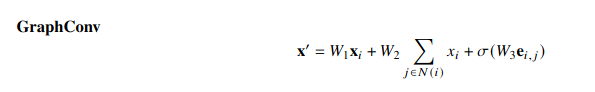

Graph Convolution as it is implemented in pytorch geometric:

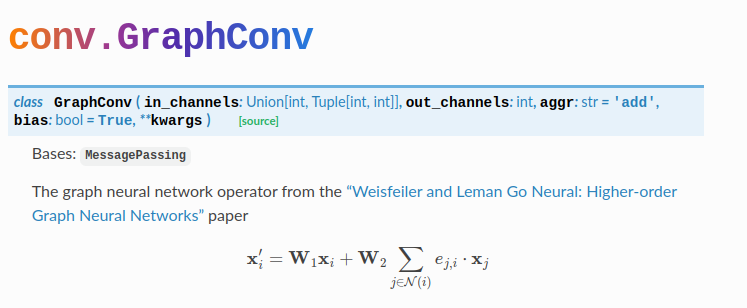

This isn't quite what we want. And, moreover, it is quite simple to define, so let's do it in a custom way.

In [15]:
# defining a custom graph layer.
# standard layers ignore edge attributes or just use them as multipliers
# i want my model to really "see" whether an edge is original (1.0) or added (0.5),
# so i'm building a layer that treats edge weights as learned features.
class CustomGraphConv(MessagePassing):
    def __init__(self, in_channels, out_channels):
        # using "add" aggregation
        super().__init__(aggr='add')  

        # W1: process the node's own features (self-loop equivalent)
        self.lin_root = Linear(in_channels, out_channels)  
        # W2: process the combined info coming from neighbors
        self.lin_rel = Linear(in_channels, out_channels)   
        # W3: bridge for edge attributes.
        # the edge attr is just a single number (1 dim), but the nodes are vectors (e.g., 64 dim). 
        self.lin_edge = Linear(1, in_channels)            

    def forward(self, x, edge_index, edge_attr):
        # first, process the node itself (skip connection logic)
        # i.e. W1 * x_i
        out = self.lin_root(x)

        # then, prepare the edge info.
        # projecting the 1d weight (0.5 or 1.0) into a feature vector
        # and running it through a relu
        # i.e. ReLU(W3 * e_ij)
        edge_embedding = self.lin_edge(edge_attr).relu() 

        # start the message passing, message() -> aggregate() -> update()
        # Sum( x_j + edge_embedding ) over all neighbors
        neighbor_sum = self.propagate(edge_index, x=x, edge_attr=edge_embedding)

        # combine everything.
        # adding the processed neighbor info to the node's own info.
        # (W1 * x_i) + (W2 * Sum(x_j + ReLU(W3 * e_ij)))
        out = out + self.lin_rel(neighbor_sum)
        return out

    def message(self, x_j, edge_attr):
        # this defines what a single message looks like before summation.
        # message = neighbor feature + edge feature
        return x_j + edge_attr

# the full model wrapper for the Graph Convolution
# this stacks the custom layers we just defined
class GNN_GraphConv_RCOV(torch.nn.Module):
    def __init__(self, num_features, num_classes, hidden_channels=64, num_layers=3, dropout=0.0):
        super().__init__()
        self.dropout_val = dropout
        self.convs = torch.nn.ModuleList()
        
        # The first layer takes num_features as input and outputs hidden_channels.
        self.convs.append(CustomGraphConv(num_features, hidden_channels))

        # stacking the layers.
        # using the custom class i defined above.
        for _ in range(num_layers):
            self.convs.append(CustomGraphConv(hidden_channels, hidden_channels))

        # final classifier (map hidden features to classes)
        self.lin = Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch, edge_attr):
        # run through graph conv layers
        for conv in self.convs:
            x = conv(x, edge_index, edge_attr).relu()

        # pool nodes into a graph-level vector
        x = global_add_pool(x, batch)

        # dropout and classifier
        x = F.dropout(x, p=self.dropout_val, training=self.training)
        x = self.lin(x)
        return x

Graph Isomorphism Networks GIN as defined in the paper:

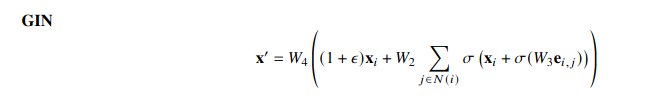

Graph Isomorphism Networks as defined in pytorch geometric:

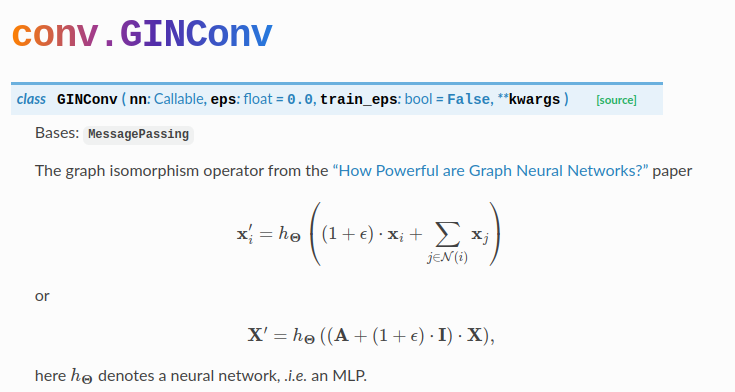

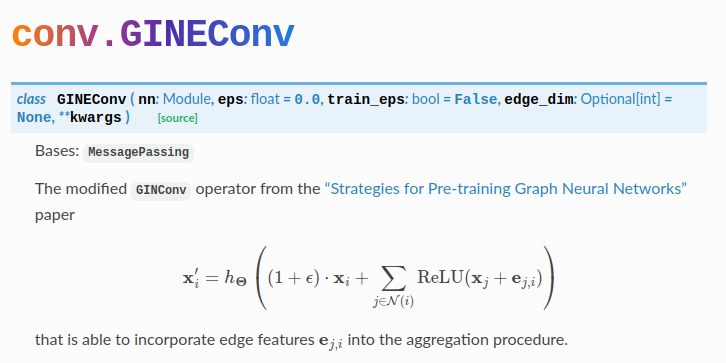

It seems that GINConv and GINEConv assume that the matrix $W_2$ is the identity matrix, and, additionally, we need to do something about a transformation of the edge features.

In [16]:
# building the gin layer from scratch because the pytorch geometric version
# hides the matrices i need (specifically W2) and i want to be 100% sure
# i'm matching the paper's formula exactly.
class CustomGINConv(MessagePassing):
    def __init__(self, in_channels, out_channels):
        # using 'add' aggregation because the formula shows a big summation symbol
        super().__init__(aggr='add') 
        
        # the formula has a term (1 + epsilon) * x_i.
        # epsilon is a learnable number, so i'm making it a parameter.
        # starting it at 0.0 is standard practice.
        # it seems to als reflect a sort of W_1
        self.eps = torch.nn.Parameter(torch.Tensor([0.0]))
        
        # this is the W_2 matrix from the screenshot.
        # it multiplies the sum of the neighbors.
        # the standard library version skips this, but the paper uses it explicitly.
        self.lin_neighbor = Linear(in_channels, in_channels)
        
        # this is W_3.
        # it takes the simple edge weight (1d) and projects it to a vector
        # so we can add it to the node features.
        self.lin_edge = Linear(1, in_channels)
        
        # this is W_4.
        self.lin = Linear(in_channels, out_channels)

    def forward(self, x, edge_index, edge_attr):
        # handle the edge part first.
        # the formula has an "inner sigma" (relu) around the edge projection: sigma(W_3 * e_ij).
        # doing this upfront.
        edge_embedding = self.lin_edge(edge_attr).relu()
        
        # start the message passing.
        # this triggers the message() function below for every connection.
        # it calculates the sum of all neighbors.
        neighbor_sum = self.propagate(edge_index, x=x, edge_attr=edge_embedding)
        
        # apply W_2.
        # the formula says: W_2 * Sum(...)
        # so i'm running the neighbor sum through that linear layer.
        neighbor_term = self.lin_neighbor(neighbor_sum)
        
        # handle the node itself (self-loop).
        # the formula says: (1 + epsilon) * x_i
        self_term = (1 + self.eps) * x
        
        # final combination.
        # adding the self-part and the neighbor-part, then running it all through W_4 (the mlp).
        out = self.lin(self_term + neighbor_term)
        
        return out

    def message(self, x_j, edge_attr):
        # looking at the sum in the screenshot:
        # Sum( sigma( x_j + sigma(W3 * e_ij) ) )
        # x_j is the neighbor's features.
        # edge_attr is the "sigma(W3 * e_ij)" part i calculated earlier.
        # now i just need to add them and apply the outer sigma (relu).
        return (x_j + edge_attr).relu()


# stack these custom layers into a full model
class GNN_GIN_RCOV(torch.nn.Module):
    def __init__(self, num_features, num_classes, hidden_channels=64, num_layers=3, dropout=0.0):
        super().__init__()
        self.dropout_val = dropout
        self.convs = torch.nn.ModuleList()
        
        # The first layer takes num_features as input and outputs hidden_channels.
        self.convs.append(CustomGINConv(num_features, hidden_channels))
        
        # stacking the custom layers i built above
        for _ in range(num_layers):
            self.convs.append(CustomGINConv(hidden_channels, hidden_channels))
            
        # final classifier to pick the class
        self.lin = Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch, edge_attr):
        # run the graph layers
        for conv in self.convs:
            # passing the edge attributes to every layer
            x = conv(x, edge_index, edge_attr)
            
        # pool, dropout and classify
        x = global_add_pool(x, batch)
        x = F.dropout(x, p=self.dropout_val, training=self.training)
        x = self.lin(x)
        return x

Graph Attention Networks as defined in the paper:

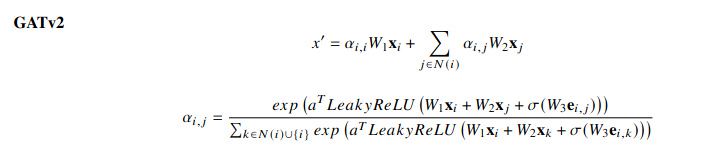

Graph Attention Networks as defined by pytorch geometric:

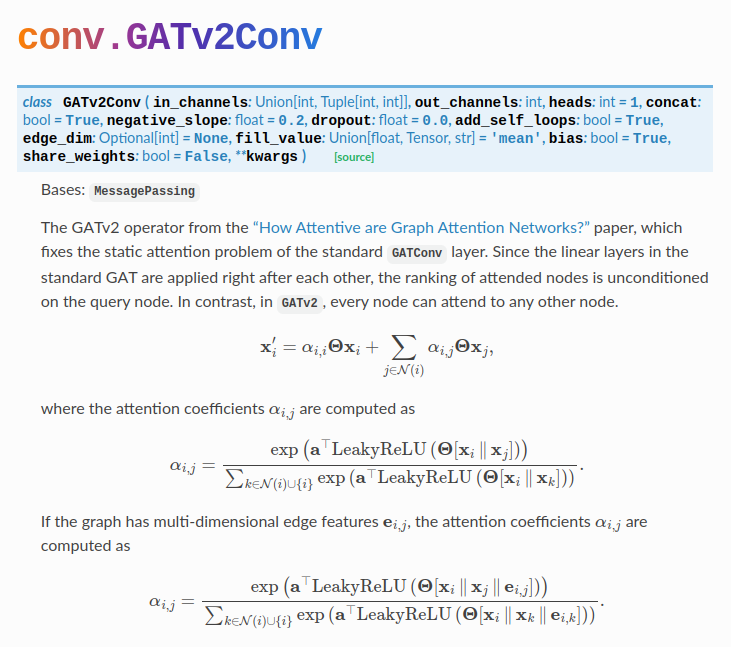

The GATv2 is implemented well, but the issue is the even by setting concat=False and fill_value="add", we still won't get the formula as it is in the paper. The issue is avoiding a $W * RELU (W * e_{i,j})$, and staying with $RELU (W * e_{i,j})$.

We implement as closely as possible:

In [17]:
# customize the gatv2 message passing function to introduce non-linearity on edges
class GATv2ConvModified(GATv2Conv):
    def edge_update(self, x_j: Tensor, x_i: Tensor, edge_attr: OptTensor,
                    index: Tensor, ptr: OptTensor,
                    dim_size: Optional[int]) -> Tensor:
        # x_i and x_j are already projected by W_s and W_t
        x = x_i + x_j

        if edge_attr is not None:
            # handle scalar edge features if they come in flat
            if edge_attr.dim() == 1:
                edge_attr = edge_attr.view(-1, 1)
            
            # project the edges to the head dimension
            assert self.lin_edge is not None
            edge_attr = self.lin_edge(edge_attr)
            edge_attr = edge_attr.view(-1, self.heads, self.out_channels)
            
            # add non-linear edge to attention score
            # here is where i apply the relu to the edge part as in paper
            # formula: LeakyReLU( W_s*xi + W_t*xj + ReLU(W_e*eij) )
            x = x + F.relu(edge_attr)

        x = F.leaky_relu(x, self.negative_slope)
        
        # calculate alpha (attention weights)
        alpha = (x * self.att).sum(dim=-1)
        alpha = softmax(alpha, index, ptr, dim_size)
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)
        return alpha

# ... and the wrapper
class GNN_GAT_RCOV(torch.nn.Module):
    def __init__(self, num_features, num_classes, num_edge_features=1, hidden_channels=64, num_layers=3, dropout=0.0, heads=4):
        super().__init__()
        self.dropout_val = dropout
        self.hidden_channels = hidden_channels
        self.heads = heads
        self.convs = ModuleList()

        # The first layer takes num_features as input and outputs hidden_channels.
        self.convs.append(
            GATv2ConvModified(
                in_channels=num_features,
                out_channels=hidden_channels,
                heads=heads,
                dropout=dropout,
                concat=True,
                edge_dim=1
            )
        )

        # stack of gatv2 layers (hidden -> hidden)
        # since i projected input x already, the first layer is also hidden->hidden
        for _ in range(num_layers):
            self.convs.append(
                GATv2ConvModified(
                    in_channels=hidden_channels, 
                    out_channels=hidden_channels, 
                    heads=heads, 
                    dropout=dropout, 
                    concat=True, 
                    edge_dim=1
                )
            )

        # final classifier to pick the class
        self.lin = Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch, edge_attr):
        # pre-process edges, reshape
        if edge_attr is not None and edge_attr.dim() == 1:
            edge_attr = edge_attr.view(-1, 1)
        
        # message passing stack
        for conv in self.convs:
            # pass projected nodes (x) and raw edges (edge_attr)
            # the conv handles the projection and relu internally
            # output shape is [N, heads * hidden_channels] because concat=True
            x_cat = conv(x, edge_index, edge_attr=edge_attr)
            
            # sum the concatenation
            # reshape to [N, heads, hidden_channels] and sum over heads (dim 1)
            x = x_cat.view(-1, self.heads, self.hidden_channels).sum(dim=1)

        # dropout, global pooling & prediction
        x = global_add_pool(x, batch)
        x = F.dropout(x, p=self.dropout_val, training=self.training)
        x = self.lin(x)
        
        return x

Graph Transformer as in the paper:

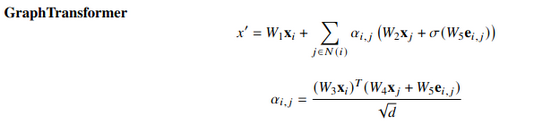

Graph Transformer as in pytorch geometric:

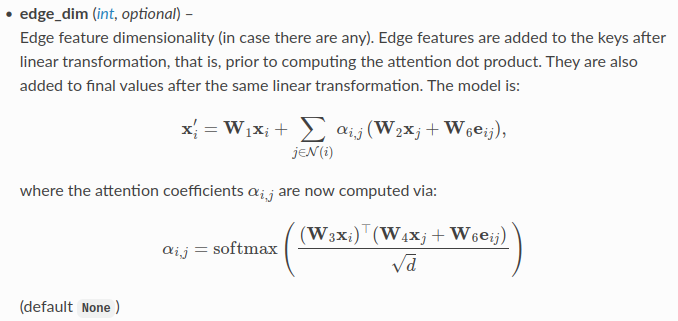

In [18]:
# customize the transformerconv message passing function, and introduce non-linearity
# copied from https://pytorch-geometric.readthedocs.io/en/2.4.0/_modules/torch_geometric/nn/conv/transformer_conv.html#TransformerConv
class TransformerConvModified(TransformerConv):
    def message(self, query_i, key_j, value_j, edge_attr, index, ptr, size_i):
        
        # project edges (W_5 * e_ij)
        if self.lin_edge is not None:
            assert edge_attr is not None
            # project the edges to the head dimension
            edge_attr = self.lin_edge(edge_attr).view(-1, self.heads, self.out_channels)
            
            # add linear edge to key (matches the numerator in the alpha formula)
            # i do not apply relu here, strictly linear addition, as in paper
            key_j = key_j + edge_attr

        # standard attention calculation
        alpha = (query_i * key_j).sum(dim=-1) / math.sqrt(self.out_channels)
        alpha = softmax(alpha, index, ptr, size_i)
        self._alpha = alpha
        alpha = F.dropout(alpha, p=self.dropout, training=self.training)

        out = value_j
        
        # add non-linear edge to value
        # here is where i apply the relu to the edge part as in paper
        if edge_attr is not None:
            # matches formula: (W2*xj + sigma(W5*eij))
            # applying ReLU specifically here
            out = out + F.relu(edge_attr)

        out = out * alpha.view(-1, self.heads, 1)
        return out

# ... and the wrapper
class GNN_Transformer_RCOV(torch.nn.Module):
    def __init__(self, num_features, num_classes, hidden_channels=64, num_layers=3, dropout=0.0, heads=4):
        super().__init__()
        self.dropout_val = dropout
        self.hidden_channels = hidden_channels
        self.heads = heads
        self.convs = ModuleList()

        # The first layer takes num_features as input and outputs hidden_channels.
        self.convs.append(
            TransformerConvModified(
                in_channels=num_features,
                out_channels=hidden_channels,
                heads=heads,
                dropout=dropout,
                concat=True,
                edge_dim=1,
                beta=False
            )
        )

        # stack of transformer layers (hidden -> hidden)
        for _ in range(num_layers):
            self.convs.append(
                TransformerConvModified(
                    in_channels=hidden_channels, 
                    out_channels=hidden_channels, 
                    heads=heads, 
                    dropout=dropout, 
                    concat=True, 
                    edge_dim=1, 
                    beta=False 
                )
            )

        # final classifier to pick the class
        self.lin = Linear(hidden_channels, num_classes)

    def forward(self, x, edge_index, batch, edge_attr):
        # pre-process edges, reshape
        if edge_attr is not None and edge_attr.dim() == 1:
            edge_attr = edge_attr.view(-1, 1)

        # message passing stack
        for conv in self.convs:
            # pass projected nodes (x) and projected edges (edge_embeddings)
            # output shape is [N, heads * hidden_channels] because concat=True
            x = conv(x, edge_index, edge_attr=edge_attr)            
            
            # sum the concatenation
            # reshape to [N, heads, hidden_channels] and sum over heads (dim 1)
            x = x.view(-1, self.heads, self.hidden_channels).sum(dim=1)


        # dropout, global pooling & prediction
        x = global_add_pool(x, batch)
        x = F.dropout(x, p=self.dropout_val, training=self.training)
        x = self.lin(x)
        
        return x

In [19]:
def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch, data.edge_attr)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

In [20]:
@torch.no_grad()
def test(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch, data.edge_attr)
        # Loss for early stopping
        loss = criterion(out, data.y)
        total_loss += loss.item() * data.num_graphs
        # Acc
        pred = out.argmax(dim=1)
        correct += int((pred == data.y).sum())
        
    return total_loss / len(loader.dataset), correct / len(loader.dataset)

In [21]:
def run_fold(dataset, train_idx, val_idx, model_cls, hidden_channels, lr, dropout, num_layers=3, epochs=1000, patience=100):
    # slice the dataset using the provided indices for this specific fold
    train_dataset = [dataset[i] for i in train_idx]
    val_dataset = [dataset[i] for i in val_idx]
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    
    # dynamically instantiate the model class
    model = model_cls(num_features=dataset.num_features, 
                      num_classes=dataset.num_classes, 
                      hidden_channels=hidden_channels,
                      num_layers=num_layers,
                      dropout=dropout).to(device)
    
    # standard adam optimizer with a bit of weight decay for regularization as in the paper
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = torch.nn.CrossEntropyLoss()
    
    best_val_loss = float('inf')
    best_val_acc = 0.0
    patience_counter = 0
    
    for epoch in range(1, epochs + 1):
        train_loss = train(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = test(model, val_loader, criterion, device)
        
        # early stopping
        # if val loss decreases, we save the state and reset the patience timer.
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc 
            patience_counter = 0
        else:
            patience_counter += 1
            
        # we also track the absolute highest accuracy seen, even if it didn't occur at the lowest loss
        if val_acc > best_val_acc:
             best_val_acc = val_acc
            
        if patience_counter >= patience:
            break
            
    return best_val_acc

In [22]:
# first we check that everything is working smoothly before we run the grid search
# configuration for sanity check
models_to_test = {
    "Transformer": GNN_Transformer_RCOV,
    "GAT": GNN_GAT_RCOV,
    "GIN": GNN_GIN_RCOV,
    "GraphConv": GNN_GraphConv_RCOV
}

# keeping the model small and training brief just to verify the code runs without errors.
config = {
    'lr': 0.001,
    'dropout': 0.0,
    'hidden_channels': 32, 
    'num_layers': 1,       
    'epochs': 1            
}

num_folds = 10

# we use the original dataset for the check, but you can swap this to "rcov_0.8" etc.
dataset_name = "Original"
dataset = all_datasets[dataset_name]
labels = [data.y.item() for data in dataset]

# set up stratified k-fold to ensure class distribution remains consistent across splits.
skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

print(f"Running Sanity Check: {num_folds}-Fold CV, 1 Epoch, 1 Layer")
print("="*60)

results = {}

for model_name, model_cls in models_to_test.items():
    print(f"\nTesting {model_name}...")
    fold_accuracies = []
    
    start_time = time.time()
    
    # iterate through the 10 folds using the stratified split we defined earlier.
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(dataset, labels)):
        # we reuse your existing run_fold function.
        # note: i set patience higher than epochs strictly to bypass the early stopping logic for this sanity check.
        acc = run_fold(
            dataset=dataset, 
            train_idx=train_idx, 
            val_idx=val_idx, 
            model_cls=model_cls, 
            hidden_channels=config['hidden_channels'], 
            lr=config['lr'], 
            dropout=config['dropout'],
            num_layers=config['num_layers'],
            epochs=config['epochs'], 
            patience=10 
        )
        fold_accuracies.append(acc)
        # print(f"  Fold {fold_idx+1}/{FOLDS}: Acc = {acc:.4f}") # optional: print per fold

    # aggregate the results across folds to get the mean and standard deviation.
    avg_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)
    elapsed = time.time() - start_time
    
    results[model_name] = f"{avg_acc*100:.2f} ± {std_acc*100:.2f}"
    
    print(f"  > Completed {model_name} in {elapsed:.2f}s | Avg Acc: {avg_acc*100:.2f}%")

print("\n" + "="*60)
print("Final Results (1 Epoch Sanity Check):")
for m, r in results.items():
    print(f"{m:<15}: {r}")

Running Sanity Check: 10-Fold CV, 1 Epoch, 1 Layer

Testing Transformer...


/home/edik/projects/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:283: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  warnings.warn(


  > Completed Transformer in 16.19s | Avg Acc: 51.95%

Testing GAT...
  > Completed GAT in 21.19s | Avg Acc: 56.65%

Testing GIN...
  > Completed GIN in 6.70s | Avg Acc: 52.60%

Testing GraphConv...
  > Completed GraphConv in 6.57s | Avg Acc: 54.40%

Final Results (1 Epoch Sanity Check):
Transformer    : 51.95 ± 8.26
GAT            : 56.65 ± 11.33
GIN            : 52.60 ± 9.15
GraphConv      : 54.40 ± 7.60


In [23]:
# grid search part and running the actual model
# config
models_to_test = {
    "GraphConv": GNN_GraphConv_RCOV, 
    "GIN": GNN_GIN_RCOV,
    "GAT": GNN_GAT_RCOV,
    "Transformer": GNN_Transformer_RCOV,
    "DeepSets": DeepSets
}

# the hyperparameter values we want to sweep through to find the best configuration.
param_grid = {
    'lr': [1e-3, 1e-4],
    'dropout': [0.0, 0.5],
    'layers': [3, 5]
}

# --- experiment constants ---
num_folds = 10
num_epochs = 1000
num_patience = 100

# initializing a dictionary to store the best (mean, std, params) tuple for every model-dataset combination.
results = {m: {d: (0.0, 0.0, "") for d in all_datasets.keys()} for m in models_to_test.keys()}

# we need the labels from the original dataset upfront so the stratified k-fold splitter 
# knows how to balance the classes in every fold regardless of which dataset version we use later.
labels = [data.y.item() for data in dataset_orig]
skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

print(f"Configuration: {num_folds}-Fold CV, {num_epochs} Epochs, Patience {num_patience}")
print("="*60)
start_time = time.time()

for model_name, model_cls in models_to_test.items():
    print(f"\nModel: {model_name}")
    
    # deepsets treats graphs as sets (ignoring edges), so running it on the edge-modified (rcov) datasets 
    # is redundant. we restrict it to run only on the original dataset.
    datasets_for_model = ["Original"] if model_name == "DeepSets" else all_datasets.keys()
    
    for data_name in datasets_for_model:
        dataset = all_datasets[data_name]
        
        # variables to track the best performance found across the grid search for this specific model/dataset pair.
        best_avg_acc = 0.0
        best_std_acc = 0.0
        best_params = ""
        
        # hyperparameter grid
        # we iterate through every combination of learning rate, dropout, and layer count.
        for lr in param_grid['lr']:
            for dropout in param_grid['dropout']:
                for layers in param_grid['layers']:
                    start_inner = time.time()
                    fold_accuracies = []
                    
                    # cross validation loop: split the data 10 times and train a fresh model each time.
                    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(dataset, labels)):
                        acc = run_fold(dataset, train_idx, val_idx, model_cls, 
                                       hidden_channels=64, 
                                       lr=lr, 
                                       dropout=dropout,
                                       num_layers=layers,
                                       epochs=num_epochs, 
                                       patience=num_patience)
                        fold_accuracies.append(acc)
                    
                    avg_acc = np.mean(fold_accuracies)
                    std_acc = np.std(fold_accuracies)

                    end_inner = time.time()
                    
                    print(f"  > {data_name} | LR={lr}, Drop={dropout}, L={layers} | Time={end_inner-start_inner}s | Result: {avg_acc*100:.2f} ± {std_acc*100:.2f}")
                    
                    # if this specific combination of parameters yielded a better average accuracy than 
                    # what we've seen so far, we update our 'best' record.
                    if avg_acc > best_avg_acc:
                        best_avg_acc = avg_acc
                        best_std_acc = std_acc
                        best_params = f"(lr={lr}, drop={dropout}, L={layers})"
        
        # finally, save the absolute best result from the grid search into our main results dictionary.
        results[model_name][data_name] = (best_avg_acc, best_std_acc, best_params)
        print(f"  * Best for {model_name} on {data_name}: {best_avg_acc*100:.2f} ± {best_std_acc*100:.2f} {best_params}")

total_time = (time.time() - start_time) / 60 / 60
print(f"\nTotal Run Time: {total_time:.2f} hours")

Configuration: 10-Fold CV, 1000 Epochs, Patience 100

Model: GraphConv
  > Original | LR=0.001, Drop=0.0, L=3 | Time=2371.3832552433014s | Result: 80.65 ± 3.19
  > Original | LR=0.001, Drop=0.0, L=5 | Time=3811.5813448429108s | Result: 74.65 ± 12.79
  > Original | LR=0.001, Drop=0.5, L=3 | Time=1623.3576800823212s | Result: 71.65 ± 5.84
  > Original | LR=0.001, Drop=0.5, L=5 | Time=2873.898665904999s | Result: 66.35 ± 8.41
  > Original | LR=0.0001, Drop=0.0, L=3 | Time=4478.759665250778s | Result: 79.80 ± 4.84
  > Original | LR=0.0001, Drop=0.0, L=5 | Time=4693.921677112579s | Result: 74.05 ± 4.51
  > Original | LR=0.0001, Drop=0.5, L=3 | Time=2557.1403765678406s | Result: 71.55 ± 4.71
  > Original | LR=0.0001, Drop=0.5, L=5 | Time=4767.156031370163s | Result: 69.05 ± 7.20
  * Best for GraphConv on Original: 80.65 ± 3.19 (lr=0.001, drop=0.0, L=3)
  > RCOV_0.8 | LR=0.001, Drop=0.0, L=3 | Time=2924.274500608444s | Result: 83.00 ± 3.81
  > RCOV_0.8 | LR=0.001, Drop=0.0, L=5 | Time=3258.73

KeyboardInterrupt: 

In [ ]:
print("\n" + "="*95)
print(f"{'Model':<20} | {'Dataset':<15} | {'Accuracy (Mean ± Std)':<25} | {'Best Params'}")
print("="*95)

# 1. print deepset (empty graph)
# we handle deepsets manually here. since it acts as our baseline (ignoring structure entirely),
# it essentially treats every input as an "empty graph," so it doesn't make sense to list it under the rcov variations.
acc, std, params = results["DeepSets"]["Original"]
print(f"{'DeepSets':<20} | {'Empty Graph':<15} | {acc*100:.2f} ± {std*100:.2f}{'':<10} | {params}")
print("-" * 95)

# 2. print others
# we define a specific order for models and datasets to ensure the table is easy to read,
# rather than relying on the random order of python dictionaries.
other_models = ["GraphConv", "GIN", "GAT", "Transformer"]
dataset_order = ["Original", "RCOV_0.8", "RCOV_0.5"]

for model in other_models:
    for ds_name in dataset_order:
        acc, std, params = results[model][ds_name]
        # formatting the float accuracy to a percentage with 2 decimal places for cleaner viewing.
        print(f"{model:<20} | {ds_name:<15} | {acc*100:.2f} ± {std*100:.2f}{'':<10} | {params}")
    print("-" * 95)